1. Title and objective

# CICIoMT2024 - Full Attack-Type Multiclass Classification

## Objective
This notebook develops baseline machine learning models for full attack-type multiclass classification on the CICIoMT2024 dataset. Unlike the grouped multiclass task, this setting requires the model to distinguish individual attack types and benign traffic at a finer level of granularity.

The notebook compares a linear baseline and tree-based models, evaluates performance using macro and weighted multiclass metrics, and analyses which attack types remain difficult to classify under severe class imbalance.

2. Imports

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

3. Display settings

In [2]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 1000)

plt.style.use("default")
sns.set_theme(style="whitegrid")

4. Load processed full multiclass datasets

## Load processed full multiclass datasets

In [3]:
PROCESSED_DIR = Path("../data/processed")
REPORT_DIR = Path("../reports/results")

X_train_tree = pd.read_csv(PROCESSED_DIR / "X_train_tree_full.csv")
X_test_tree = pd.read_csv(PROCESSED_DIR / "X_test_tree_full.csv")
y_train = pd.read_csv(PROCESSED_DIR / "y_train_full.csv").squeeze("columns")
y_test = pd.read_csv(PROCESSED_DIR / "y_test_full.csv").squeeze("columns")

X_train_linear = pd.read_csv(PROCESSED_DIR / "X_train_linear_full_scaled.csv")
X_test_linear = pd.read_csv(PROCESSED_DIR / "X_test_linear_full_scaled.csv")

full_mapping = pd.read_csv(REPORT_DIR / "full_label_mapping.csv")

print("Tree train:", X_train_tree.shape)
print("Tree test:", X_test_tree.shape)
print("Linear train:", X_train_linear.shape)
print("Linear test:", X_test_linear.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

full_mapping.head(20)

Tree train: (2708250, 73)
Tree test: (677063, 73)
Linear train: (2708250, 53)
Linear test: (677063, 53)
y_train: (2708250,)
y_test: (677063,)


,full_class_name,full_class_code
0,Benign Traffic,0
1,DDoS ICMP Flood,1
2,DDoS UDP Flood,2
3,DoS ICMP Flood,3
4,DoS TCP Flood,4
5,DoS UDP Flood,5
6,MITM ARP Spoofing,6
7,MQTT DDoS Publish Flood,7
8,MQTT DoS Connect Flood,8
9,MQTT DoS Publish Flood,9


5. Class-name helpers

In [4]:
class_names = full_mapping.sort_values("full_class_code")["full_class_name"].tolist()
class_code_to_name = dict(zip(full_mapping["full_class_code"], full_mapping["full_class_name"]))

print("Number of classes:", len(class_names))
print("Class names:")
print(class_names)

Number of classes: 15
Class names:
['Benign Traffic', 'DDoS ICMP Flood', 'DDoS UDP Flood', 'DoS ICMP Flood', 'DoS TCP Flood', 'DoS UDP Flood', 'MITM ARP Spoofing', 'MQTT DDoS Publish Flood', 'MQTT DoS Connect Flood', 'MQTT DoS Publish Flood', 'MQTT Malformed', 'Recon OS Scan', 'Recon Ping Sweep', 'Recon Port Scan', 'Recon Vulnerability Scan']


6. Confirm target distribution

In [5]:
print("Training full multiclass target distribution:")
print(y_train.value_counts().sort_index())

print("\nTest full multiclass target distribution:")
print(y_test.value_counts().sort_index())

Training full multiclass target distribution:
target_multiclass_full_encoded
0       26096
1        2042
2        2061
3        1686
4     1685532
5        2492
6         842
7      331130
8      190425
9         762
10       1797
11      68254
12         57
13     388417
14       6657
Name: count, dtype: int64

Test full multiclass target distribution:
target_multiclass_full_encoded
0       6524
1        510
2        515
3        421
4     421384
5        623
6        211
7      82783
8      47606
9        191
10       449
11     17063
12        14
13     97105
14      1664
Name: count, dtype: int64


In [6]:
train_distribution_named = y_train.map(class_code_to_name).value_counts()
test_distribution_named = y_test.map(class_code_to_name).value_counts()

print("Named train distribution:")
print(train_distribution_named)

print("\nNamed test distribution:")
print(test_distribution_named)

Named train distribution:
target_multiclass_full_encoded
DoS TCP Flood               1685532
Recon Port Scan              388417
MQTT DDoS Publish Flood      331130
MQTT DoS Connect Flood       190425
Recon OS Scan                 68254
Benign Traffic                26096
Recon Vulnerability Scan       6657
DoS UDP Flood                  2492
DDoS UDP Flood                 2061
DDoS ICMP Flood                2042
MQTT Malformed                 1797
DoS ICMP Flood                 1686
MITM ARP Spoofing               842
MQTT DoS Publish Flood          762
Recon Ping Sweep                 57
Name: count, dtype: int64

Named test distribution:
target_multiclass_full_encoded
DoS TCP Flood               421384
Recon Port Scan              97105
MQTT DDoS Publish Flood      82783
MQTT DoS Connect Flood       47606
Recon OS Scan                17063
Benign Traffic                6524
Recon Vulnerability Scan      1664
DoS UDP Flood                  623
DDoS UDP Flood                 515
DDoS 

7. Helper functions

## Evaluation helpers

In [7]:
def evaluate_multiclass_model(model_name, y_true, y_pred):
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }

In [8]:
def classification_report_df(y_true, y_pred, class_names):
    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
    return pd.DataFrame(report).T

In [9]:
def plot_multiclass_confusion(y_true, y_pred, class_names, title, normalize=None, figsize=(12, 10)):
    cm = confusion_matrix(y_true, y_pred, normalize=normalize)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=figsize)
    disp.plot(cmap="Blues", ax=ax, xticks_rotation=75, colorbar=False)
    plt.title(title)
    plt.show()

8. Linear baseline - multinomial logistic regression

## Model 1: Multinomial Logistic Regression
A class-weighted multinomial logistic regression is used as the linear baseline.

In [10]:
log_reg_mc = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    multi_class="multinomial",
    random_state=42
)

log_reg_mc.fit(X_train_linear, y_train)

y_pred_log = log_reg_mc.predict(X_test_linear)

log_results = evaluate_multiclass_model("Multinomial Logistic Regression", y_test, y_pred_log)
pd.DataFrame([log_results])

c:\Users\jpetr\Desktop\DAMA\extra_projects\iomt-cybersecurity-ml\cybersecurity\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\jpetr\Desktop\DAMA\extra_projects\iomt-cybersecurity-ml\cybersecurity\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,Multinomial Logistic Regression,0.90631,0.383009,0.546075,0.388052,0.957558,0.90631,0.924273


In [11]:
log_report_df = classification_report_df(y_test, y_pred_log, class_names)
log_report_df

,precision,recall,f1-score,support
Benign Traffic,0.814081,0.705395,0.755851,6524.00000
DDoS ICMP Flood,0.128866,0.147059,0.137363,510.00000
DDoS UDP Flood,0.021559,0.050485,0.030215,515.00000
DoS ICMP Flood,0.059316,0.201900,0.091694,421.00000
DoS TCP Flood,0.999993,0.999029,0.999511,421384.00000
DoS UDP Flood,0.131127,0.171750,0.148714,623.00000
MITM ARP Spoofing,0.051813,0.236967,0.085034,211.00000
MQTT DDoS Publish Flood,0.980664,0.945943,0.962991,82783.00000
MQTT DoS Connect Flood,0.957543,0.712515,0.817054,47606.00000
MQTT DoS Publish Flood,0.102308,0.696335,0.178404,191.00000


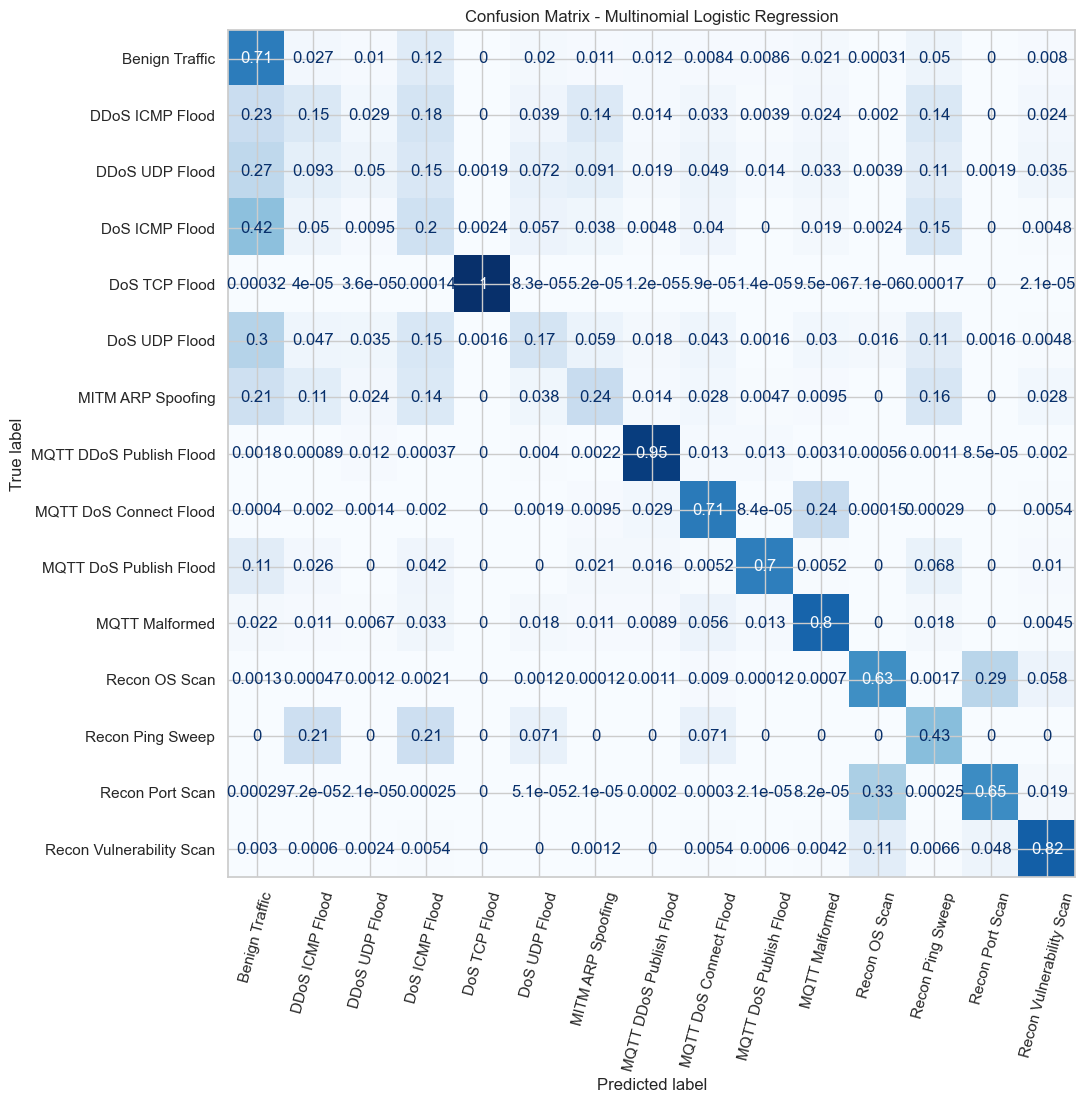

In [12]:
plot_multiclass_confusion(
    y_test, y_pred_log, class_names,
    "Confusion Matrix - Multinomial Logistic Regression",
    normalize="true",
    figsize=(13, 11)
)

9. Decision Tree baseline

## Model 2: Decision Tree
A class-weighted decision tree provides a nonlinear baseline.

In [13]:
decision_tree_mc = DecisionTreeClassifier(
    class_weight="balanced",
    max_depth=14,
    min_samples_leaf=20,
    random_state=42
)

decision_tree_mc.fit(X_train_tree, y_train)

y_pred_dt = decision_tree_mc.predict(X_test_tree)

dt_results = evaluate_multiclass_model("Decision Tree", y_test, y_pred_dt)
pd.DataFrame([dt_results])

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,Decision Tree,0.965046,0.523542,0.740165,0.569304,0.982271,0.965046,0.970265


In [14]:
dt_report_df = classification_report_df(y_test, y_pred_dt, class_names)
dt_report_df

,precision,recall,f1-score,support
Benign Traffic,0.935697,0.715972,0.811219,6524.000000
DDoS ICMP Flood,0.240406,0.417647,0.305158,510.000000
DDoS UDP Flood,0.107680,0.264078,0.152981,515.000000
DoS ICMP Flood,0.256798,0.403800,0.313943,421.000000
DoS TCP Flood,0.999988,0.999141,0.999564,421384.000000
DoS UDP Flood,0.152897,0.457464,0.229192,623.000000
MITM ARP Spoofing,0.097192,0.639810,0.168750,211.000000
MQTT DDoS Publish Flood,0.999260,0.978124,0.988579,82783.000000
MQTT DoS Connect Flood,0.998906,0.978385,0.988539,47606.000000
MQTT DoS Publish Flood,0.320652,0.926702,0.476447,191.000000


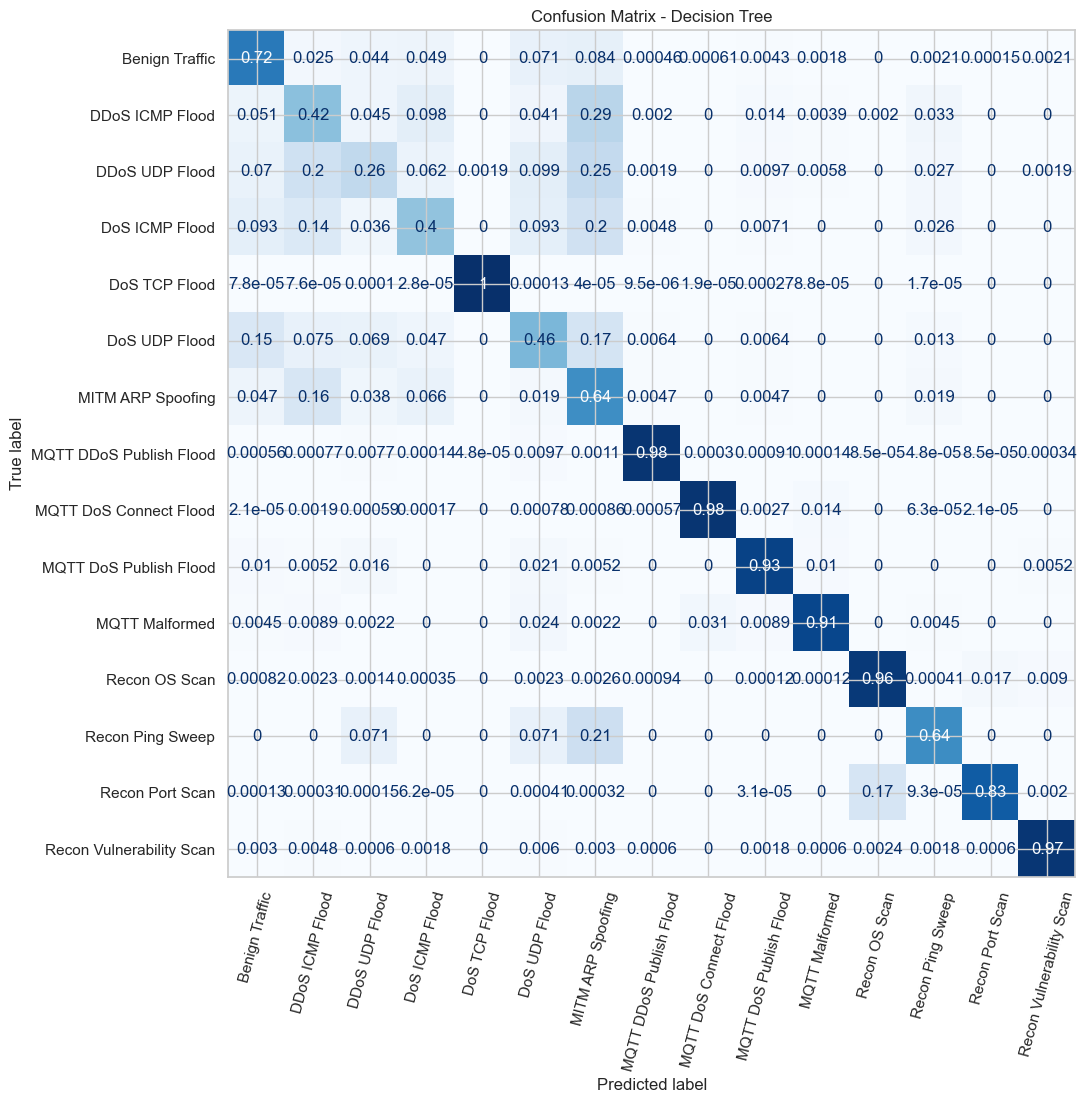

In [15]:
plot_multiclass_confusion(
    y_test, y_pred_dt, class_names,
    "Confusion Matrix - Decision Tree",
    normalize="true",
    figsize=(13, 11)
)

10. Random Forest baseline

## Model 3: Random Forest
Random Forest is used as the strongest baseline for the full attack-type classification task.

In [16]:
random_forest_mc = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)

random_forest_mc.fit(X_train_tree, y_train)

y_pred_rf = random_forest_mc.predict(X_test_tree)

rf_results = evaluate_multiclass_model("Random Forest", y_test, y_pred_rf)
pd.DataFrame([rf_results])

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,Random Forest,0.985746,0.848435,0.734346,0.778298,0.985044,0.985746,0.985076


In [17]:
rf_report_df = classification_report_df(y_test, y_pred_rf, class_names)
rf_report_df

,precision,recall,f1-score,support
Benign Traffic,0.876835,0.988657,0.929395,6524.000000
DDoS ICMP Flood,0.642336,0.517647,0.573290,510.000000
DDoS UDP Flood,0.617486,0.438835,0.513053,515.000000
DoS ICMP Flood,0.706320,0.451306,0.550725,421.000000
DoS TCP Flood,0.999789,0.999810,0.999799,421384.000000
DoS UDP Flood,0.762470,0.515249,0.614943,623.000000
MITM ARP Spoofing,0.774775,0.407583,0.534161,211.000000
MQTT DDoS Publish Flood,0.999457,0.999722,0.999589,82783.000000
MQTT DoS Connect Flood,0.997271,0.998088,0.997680,47606.000000
MQTT DoS Publish Flood,0.959302,0.863874,0.909091,191.000000


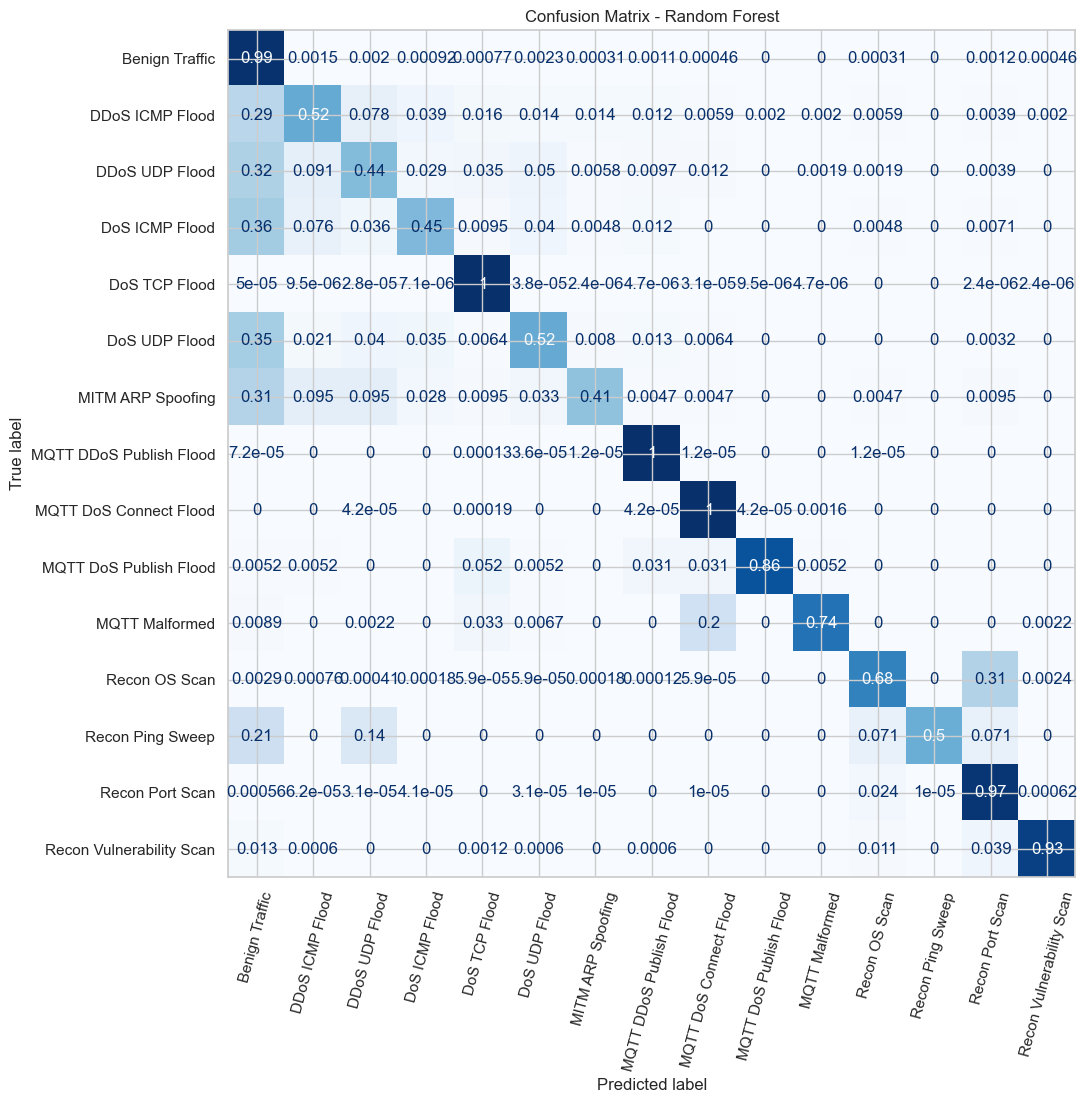

In [18]:
plot_multiclass_confusion(
    y_test, y_pred_rf, class_names,
    "Confusion Matrix - Random Forest",
    normalize="true",
    figsize=(13, 11)
)

11. Compare model performance

In [19]:
results_df = pd.DataFrame([log_results, dt_results, rf_results]).sort_values(
    ["macro_f1", "weighted_f1", "accuracy"], ascending=False
).reset_index(drop=True)

results_df

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,Random Forest,0.985746,0.848435,0.734346,0.778298,0.985044,0.985746,0.985076
1,Decision Tree,0.965046,0.523542,0.740165,0.569304,0.982271,0.965046,0.970265
2,Multinomial Logistic Regression,0.906310,0.383009,0.546075,0.388052,0.957558,0.906310,0.924273


12. Per-class performance under the best model

## Per-class Random Forest performance
This section highlights the class-specific precision, recall, F1-score, and support under the strongest baseline.

In [20]:
rf_per_class = rf_report_df.loc[class_names, ["precision", "recall", "f1-score", "support"]].copy()
rf_per_class = rf_per_class.sort_values("f1-score")
rf_per_class

,precision,recall,f1-score,support
DDoS UDP Flood,0.617486,0.438835,0.513053,515.0
MITM ARP Spoofing,0.774775,0.407583,0.534161,211.0
DoS ICMP Flood,0.706320,0.451306,0.550725,421.0
DDoS ICMP Flood,0.642336,0.517647,0.573290,510.0
DoS UDP Flood,0.762470,0.515249,0.614943,623.0
Recon Ping Sweep,0.875000,0.500000,0.636364,14.0
Recon OS Scan,0.828987,0.681826,0.748239,17063.0
MQTT Malformed,0.804819,0.743875,0.773148,449.0
MQTT DoS Publish Flood,0.959302,0.863874,0.909091,191.0
Benign Traffic,0.876835,0.988657,0.929395,6524.0


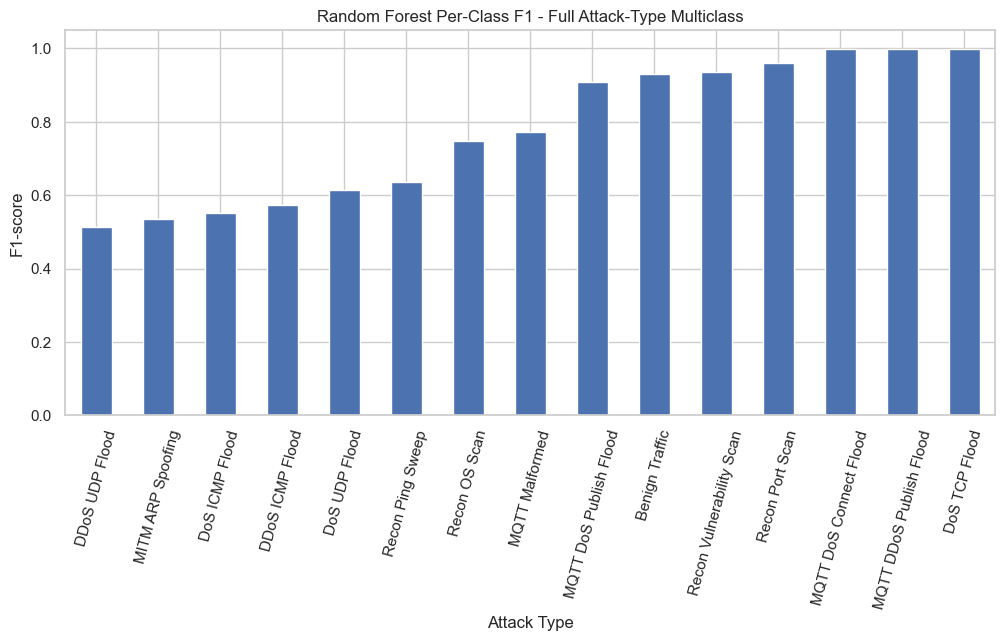

In [21]:
plt.figure(figsize=(12, 5))
rf_per_class["f1-score"].plot(kind="bar")
plt.title("Random Forest Per-Class F1 - Full Attack-Type Multiclass")
plt.ylabel("F1-score")
plt.xlabel("Attack Type")
plt.xticks(rotation=75)
plt.show()

13. Best and worst attack types

In [22]:
print("Lowest F1 classes:")
display(rf_per_class.head(8))

print("\nHighest F1 classes:")
display(rf_per_class.tail(8))

Lowest F1 classes:


,precision,recall,f1-score,support
DDoS UDP Flood,0.617486,0.438835,0.513053,515.0
MITM ARP Spoofing,0.774775,0.407583,0.534161,211.0
DoS ICMP Flood,0.706320,0.451306,0.550725,421.0
DDoS ICMP Flood,0.642336,0.517647,0.573290,510.0
DoS UDP Flood,0.762470,0.515249,0.614943,623.0
Recon Ping Sweep,0.875000,0.500000,0.636364,14.0
Recon OS Scan,0.828987,0.681826,0.748239,17063.0
MQTT Malformed,0.804819,0.743875,0.773148,449.0



Highest F1 classes:


,precision,recall,f1-score,support
MQTT Malformed,0.804819,0.743875,0.773148,449.0
MQTT DoS Publish Flood,0.959302,0.863874,0.909091,191.0
Benign Traffic,0.876835,0.988657,0.929395,6524.0
Recon Vulnerability Scan,0.935620,0.934495,0.935057,1664.0
Recon Port Scan,0.946057,0.974213,0.959929,97105.0
MQTT DoS Connect Flood,0.997271,0.998088,0.997680,47606.0
MQTT DDoS Publish Flood,0.999457,0.999722,0.999589,82783.0
DoS TCP Flood,0.999789,0.999810,0.999799,421384.0


14. Per-class F1 comparison across models

In [23]:
per_class_f1_df = pd.DataFrame({
    "class": class_names,
    "logistic_regression_f1": log_report_df.loc[class_names, "f1-score"].values,
    "decision_tree_f1": dt_report_df.loc[class_names, "f1-score"].values,
    "random_forest_f1": rf_report_df.loc[class_names, "f1-score"].values
})

per_class_f1_df

,class,logistic_regression_f1,decision_tree_f1,random_forest_f1
0,Benign Traffic,0.755851,0.811219,0.929395
1,DDoS ICMP Flood,0.137363,0.305158,0.573290
2,DDoS UDP Flood,0.030215,0.152981,0.513053
3,DoS ICMP Flood,0.091694,0.313943,0.550725
4,DoS TCP Flood,0.999511,0.999564,0.999799
5,DoS UDP Flood,0.148714,0.229192,0.614943
6,MITM ARP Spoofing,0.085034,0.168750,0.534161
7,MQTT DDoS Publish Flood,0.962991,0.988579,0.999589
8,MQTT DoS Connect Flood,0.817054,0.988539,0.997680
9,MQTT DoS Publish Flood,0.178404,0.476447,0.909091


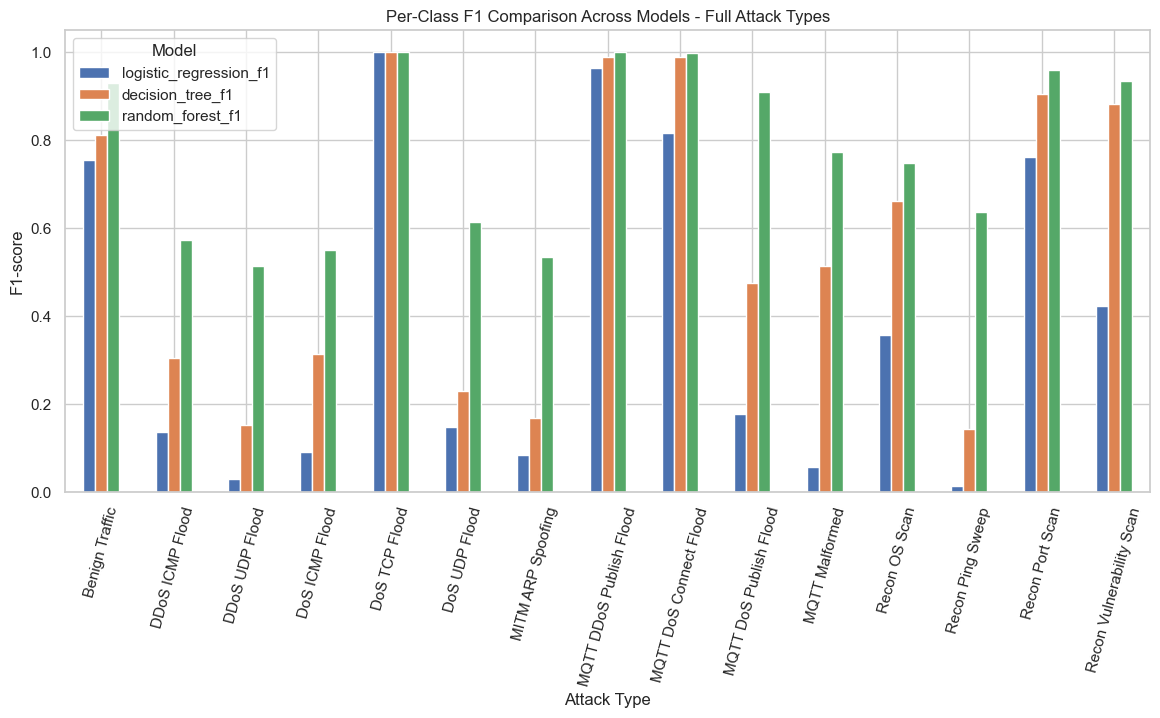

In [24]:
per_class_f1_plot = per_class_f1_df.set_index("class")
per_class_f1_plot.plot(kind="bar", figsize=(14, 6))
plt.title("Per-Class F1 Comparison Across Models - Full Attack Types")
plt.ylabel("F1-score")
plt.xlabel("Attack Type")
plt.xticks(rotation=75)
plt.legend(title="Model")
plt.show()

15. Random Forest feature importance

In [25]:
rf_importance = pd.DataFrame({
    "feature": X_train_tree.columns,
    "importance": random_forest_mc.feature_importances_
}).sort_values("importance", ascending=False)

rf_importance.head(20)

,feature,importance
20,Flow IAT Min,0.054828
2,Flow Duration,0.046460
19,Flow IAT Max,0.042783
16,Flow Packets/s,0.042649
0,Src Port,0.041682
17,Flow IAT Mean,0.040807
35,Fwd Packets/s,0.038863
36,Bwd Packets/s,0.036324
1,Dst Port,0.034544
25,Fwd IAT Min,0.026749


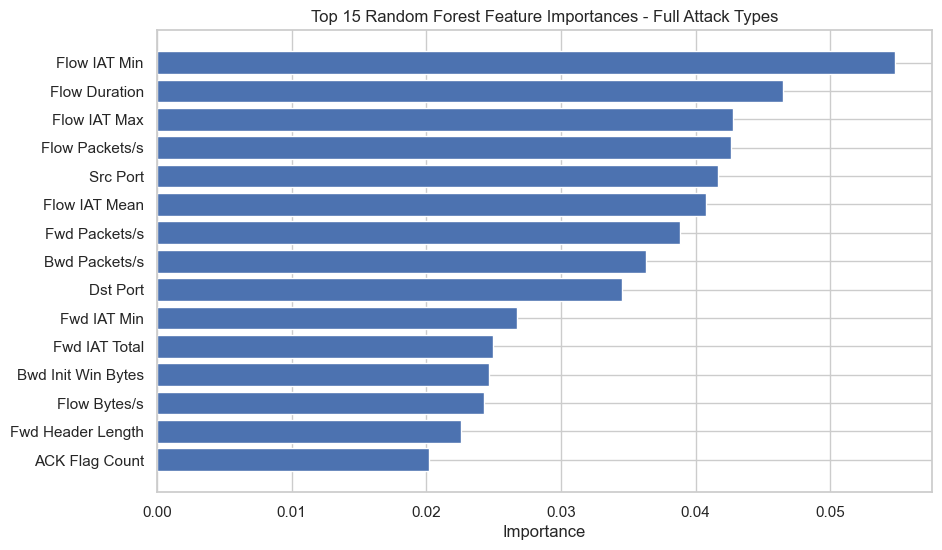

In [26]:
plt.figure(figsize=(10, 6))
top_rf = rf_importance.head(15).sort_values("importance")
plt.barh(top_rf["feature"], top_rf["importance"])
plt.title("Top 15 Random Forest Feature Importances - Full Attack Types")
plt.xlabel("Importance")
plt.show()

16. Decision Tree feature importance

In [27]:
dt_importance = pd.DataFrame({
    "feature": X_train_tree.columns,
    "importance": decision_tree_mc.feature_importances_
}).sort_values("importance", ascending=False)

dt_importance.head(15)

,feature,importance
20,Flow IAT Min,0.178356
36,Bwd Packets/s,0.155754
0,Src Port,0.120153
44,RST Flag Count,0.065855
15,Flow Bytes/s,0.065749
45,PSH Flag Count,0.058334
1,Dst Port,0.058129
2,Flow Duration,0.052895
62,Bwd Init Win Bytes,0.030157
25,Fwd IAT Min,0.024894


17. Logistic regression coefficient inspection

## Logistic regression coefficient inspection
The largest coefficient magnitudes for each class provide a class-specific view of important scaled features under the linear baseline.

In [28]:
coef_frames = []

for idx, class_name in enumerate(class_names):
    temp_df = pd.DataFrame({
        "feature": X_train_linear.columns,
        "class_name": class_name,
        "coefficient": log_reg_mc.coef_[idx],
        "abs_coefficient": np.abs(log_reg_mc.coef_[idx])
    }).sort_values("abs_coefficient", ascending=False)
    coef_frames.append(temp_df)

log_coef_all = pd.concat(coef_frames, ignore_index=True)
log_coef_all.head(20)

,feature,class_name,coefficient,abs_coefficient
0,Flow IAT Mean,Benign Traffic,6.159421,6.159421
1,Flow IAT Min,Benign Traffic,5.729859,5.729859
2,Fwd Act Data Pkts,Benign Traffic,4.762804,4.762804
3,Total Bwd packets,Benign Traffic,-3.585778,3.585778
4,Flow Duration,Benign Traffic,3.315886,3.315886
5,Total Fwd Packet,Benign Traffic,2.900663,2.900663
6,Packet Length Mean,Benign Traffic,2.892124,2.892124
7,Bwd Bulk Rate Avg,Benign Traffic,2.887900,2.887900
8,PSH Flag Count,Benign Traffic,-2.523150,2.523150
9,Total Length of Fwd Packet,Benign Traffic,-2.372537,2.372537


18. Misclassification analysis for Random Forest

## Misclassification analysis
This section identifies the most frequent confusions made by the best-performing model.

In [29]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_rf_df = pd.DataFrame(cm_rf, index=class_names, columns=class_names)
cm_rf_df

,Benign Traffic,DDoS ICMP Flood,DDoS UDP Flood,DoS ICMP Flood,DoS TCP Flood,DoS UDP Flood,MITM ARP Spoofing,MQTT DDoS Publish Flood,MQTT DoS Connect Flood,MQTT DoS Publish Flood,MQTT Malformed,Recon OS Scan,Recon Ping Sweep,Recon Port Scan,Recon Vulnerability Scan
Benign Traffic,6450,10,13,6,5,15,2,7,3,0,0,2,0,8,3
DDoS ICMP Flood,147,264,40,20,8,7,7,6,3,1,1,3,0,2,1
DDoS UDP Flood,165,47,226,15,18,26,3,5,6,0,1,1,0,2,0
DoS ICMP Flood,151,32,15,190,4,17,2,5,0,0,0,2,0,3,0
DoS TCP Flood,21,4,12,3,421304,16,1,2,13,4,2,0,0,1,1
DoS UDP Flood,219,13,25,22,4,321,5,8,4,0,0,0,0,2,0
MITM ARP Spoofing,65,20,20,6,2,7,86,1,1,0,0,1,0,2,0
MQTT DDoS Publish Flood,6,0,0,0,11,3,1,82760,1,0,0,1,0,0,0
MQTT DoS Connect Flood,0,0,2,0,9,0,0,2,47515,2,76,0,0,0,0
MQTT DoS Publish Flood,1,1,0,0,10,1,0,6,6,165,1,0,0,0,0


In [30]:
misclassifications = []

for i, true_class in enumerate(class_names):
    for j, pred_class in enumerate(class_names):
        if i != j and cm_rf[i, j] > 0:
            misclassifications.append({
                "true_class": true_class,
                "predicted_class": pred_class,
                "count": cm_rf[i, j]
            })

misclass_df = pd.DataFrame(misclassifications).sort_values("count", ascending=False)
misclass_df.head(25)

,true_class,predicted_class,count
108,Recon OS Scan,Recon Port Scan,5308
121,Recon Port Scan,Recon OS Scan,2371
56,DoS UDP Flood,Benign Traffic,219
24,DDoS UDP Flood,Benign Traffic,165
35,DoS ICMP Flood,Benign Traffic,151
11,DDoS ICMP Flood,Benign Traffic,147
97,MQTT Malformed,MQTT DoS Connect Flood,91
85,MQTT DoS Connect Flood,MQTT Malformed,76
65,MITM ARP Spoofing,Benign Traffic,65
130,Recon Vulnerability Scan,Recon Port Scan,65


19. Focus on rare classes

## Rare-class analysis
Because some attack types have very low support, this section highlights the lowest-support classes and their performance under Random Forest.

In [31]:
rf_per_class_by_support = rf_report_df.loc[class_names, ["precision", "recall", "f1-score", "support"]].copy()
rf_per_class_by_support = rf_per_class_by_support.sort_values("support")
rf_per_class_by_support.head(10)

,precision,recall,f1-score,support
Recon Ping Sweep,0.875000,0.500000,0.636364,14.0
MQTT DoS Publish Flood,0.959302,0.863874,0.909091,191.0
MITM ARP Spoofing,0.774775,0.407583,0.534161,211.0
DoS ICMP Flood,0.706320,0.451306,0.550725,421.0
MQTT Malformed,0.804819,0.743875,0.773148,449.0
DDoS ICMP Flood,0.642336,0.517647,0.573290,510.0
DDoS UDP Flood,0.617486,0.438835,0.513053,515.0
DoS UDP Flood,0.762470,0.515249,0.614943,623.0
Recon Vulnerability Scan,0.935620,0.934495,0.935057,1664.0
Benign Traffic,0.876835,0.988657,0.929395,6524.0


20. Summary table

In [32]:
summary_df = results_df.copy()
summary_df

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,Random Forest,0.985746,0.848435,0.734346,0.778298,0.985044,0.985746,0.985076
1,Decision Tree,0.965046,0.523542,0.740165,0.569304,0.982271,0.965046,0.970265
2,Multinomial Logistic Regression,0.906310,0.383009,0.546075,0.388052,0.957558,0.906310,0.924273


21. Export results

## Export model results and models for application

In [33]:
REPORT_DIR.mkdir(parents=True, exist_ok=True)

results_df.to_csv(REPORT_DIR / "full_multiclass_model_comparison.csv", index=False)
rf_report_df.to_csv(REPORT_DIR / "full_multiclass_rf_report.csv")
dt_report_df.to_csv(REPORT_DIR / "full_multiclass_dt_report.csv")
log_report_df.to_csv(REPORT_DIR / "full_multiclass_log_report.csv")
rf_importance.to_csv(REPORT_DIR / "full_multiclass_rf_importance.csv", index=False)
dt_importance.to_csv(REPORT_DIR / "full_multiclass_dt_importance.csv", index=False)
log_coef_all.to_csv(REPORT_DIR / "full_multiclass_log_coefficients.csv", index=False)
per_class_f1_df.to_csv(REPORT_DIR / "full_multiclass_per_class_f1.csv", index=False)
misclass_df.to_csv(REPORT_DIR / "full_multiclass_misclassifications.csv", index=False)

print("Full multiclass results exported.")

Full multiclass results exported.


In [34]:
from pathlib import Path
import pandas as pd

REPORT_DIR = Path("../reports/results")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

pd.DataFrame({"feature": X_train_tree.columns}).to_csv(
    REPORT_DIR / "full_rf_features.csv",
    index=False
)

print("Saved full_rf_features.csv")

Saved full_rf_features.csv


In [35]:
import joblib
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(random_forest_mc, MODEL_DIR / "full_random_forest.joblib")
print("Saved full_random_forest.joblib")

Saved full_random_forest.joblib


22. Final summary

## Summary of findings

The full attack-type multiclass task is more difficult than both the binary and grouped multiclass settings because the model must discriminate among individual attack types rather than broader attack families. This increases the impact of class imbalance and makes macro-level evaluation especially important.

The linear multinomial logistic regression provides an interpretable baseline, while the decision tree and random forest capture nonlinear structure in the network-flow data. The full multiclass setting is expected to show excellent performance on large and well-defined classes, but weaker performance on rare or behaviorally similar attack types.

For this reason, the most meaningful evaluation outputs in this notebook are macro F1, per-class performance, and the confusion analysis of the best-performing model.

### Interpretation note

If the best full multiclass model shows a clear drop in macro F1 relative to the grouped multiclass notebook, this would indicate that much of the remaining difficulty lies in distinguishing finer-grained attack variants rather than broad attack families.

### Final notes

The full attack-type multiclass results confirm that fine-grained IoMT intrusion classification is substantially more difficult than both binary detection and grouped attack-family classification. Random Forest remained the strongest model, achieving very strong weighted performance and a solid macro F1 of 0.778. However, performance dropped noticeably for rare and behaviorally similar attack variants, especially DDoS/DoS flood subtypes, MITM ARP Spoofing, and some recon subcategories. This indicates that the main challenge in the full multiclass setting is not general attack detection, but subtype discrimination under severe class imbalance and overlapping traffic behaviour.

The gap between weighted F1 and macro F1 highlights the importance of class-sensitive evaluation. While the dominant classes were classified extremely well, minority and closely related attack types remained substantially harder. This reinforces the need to look beyond accuracy when evaluating cybersecurity models on imbalanced IoMT traffic datasets.